In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
import sys, os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from NNMFit.utilities import ScanHandler

# import plotting utils
sys.path.append( "/data/user/tvaneede/utils" )
from FlavourScansPlotting import get_contour_points, get_contour_points_angle

# import scanning points
from flavor_fracs import *
points = pd.read_pickle('/data/user/tvaneede/GlobalFit/custom_scan_flavor/default_custom_scan_points_flavor.pickle')
flavs = flavor_frac(np.asarray(points['astro_nue_ratio']),np.asarray(points['astro_nutau_ratio']))

# import plotting flavor triangle
sys.path.append( "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks" )
from plot_utils_triangle import *

In [12]:
dag_path        = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit"
globalfit_hese_path = f"{dag_path}/globalfit_hese/datasets_v2/SAY"
globalfit_hese_v3_path = f"{dag_path}/globalfit_hese/datasets_v3/SAY"

scan_dir_dict = {
    # --- Globalfit+HESE ---
    "globalfit_double_no_hybrid_hese_SPL_noinel_nosyst":      f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
    "globalfit_double_no_hybrid_hese_SPL_noinel":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL_noinel",
    "globalfit_double_no_hybrid_hese_SPL_nosyst":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_SPL_nosyst",

    "globalfit_double_no_hybrid_hese_BPL_noinel_nosyst":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst_minimizer_hybrid",
    "globalfit_double_no_hybrid_hese_BPL_noinel":             f"{globalfit_hese_path}/globalfit_double_no_hybrid_hese_BPL_noinel_minimizer_hybrid_nlight_20",

    "globalfit_double_no_hybrid_hese_SPL_noinel_nosyst_v3":      f"{globalfit_hese_v3_path}/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
    "globalfit_double_no_hybrid_hese_SPL_noinel_v3":             f"{globalfit_hese_v3_path}/globalfit_double_no_hybrid_hese_SPL_noinel",
    "globalfit_double_no_hybrid_hese_SPL_nosyst_v3":             f"{globalfit_hese_v3_path}/globalfit_double_no_hybrid_hese_SPL_nosyst",


}

In [13]:
plotting_path = "/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/presentations/2026-04-08_diffuse_update/globalfit_hese"
os.system(f"mkdir -p {plotting_path}")

0

In [14]:
# load the data
N_grid = 22 # 20 was standard
drop_unsuccessful = False
scan_dict = {}
data = {}
for name, scan_dir in scan_dir_dict.items():
    print(name)
    print(scan_dir)
    scan_dict[name] = ScanHandler(scan_dir,dump=False,drop_unsuccessful=drop_unsuccessful)
    data[name] = {}
    if "newflavorparam" in name or "gf" in name:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points_angle(scan_dict,name)
    else:
        data[name]["ftau"],data[name]["fe"],data[name]["ts"],data[name]["ftau_grid"],data[name]["fe_grid"],data[name]["ts_grid"] = get_contour_points(scan_dict,name, N_grid=N_grid)


globalfit_double_no_hybrid_hese_SPL_noinel_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst
removed stuff
globalfit_double_no_hybrid_hese_SPL_noinel
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_noinel
removed stuff
globalfit_double_no_hybrid_hese_SPL_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_SPL_nosyst
removed stuff
globalfit_double_no_hybrid_hese_BPL_noinel_nosyst
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavor_globalfit/globalfit_hese/datasets_v2/SAY/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst_minimizer_hybrid
removed stuff
globalfit_double_no_hybrid_hese_BPL_noinel
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/dag_scans/flavo

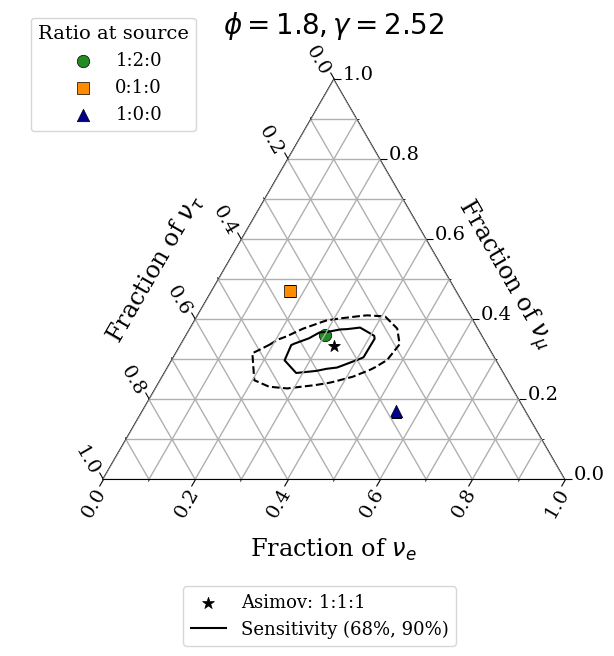

In [8]:
names = [
"globalfit_double_no_hybrid_hese_SPL_noinel",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_hese_SPL_noinel.png")


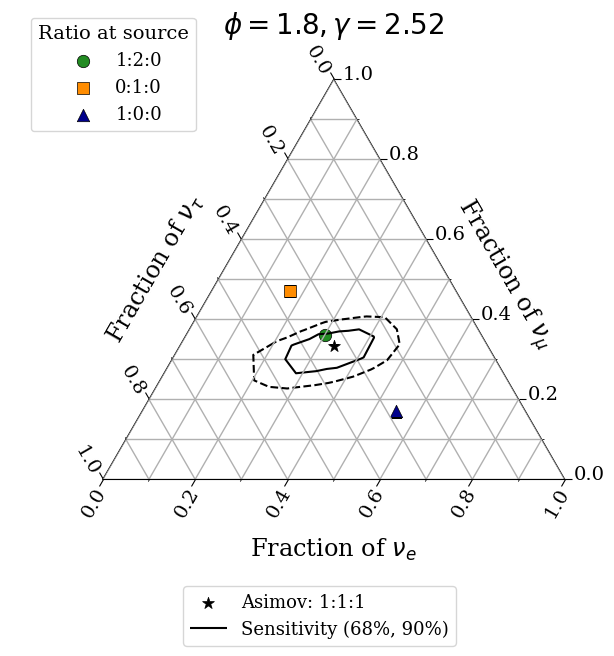

In [9]:
names = [
"globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_hese_SPL_noinel_nosyst.png")

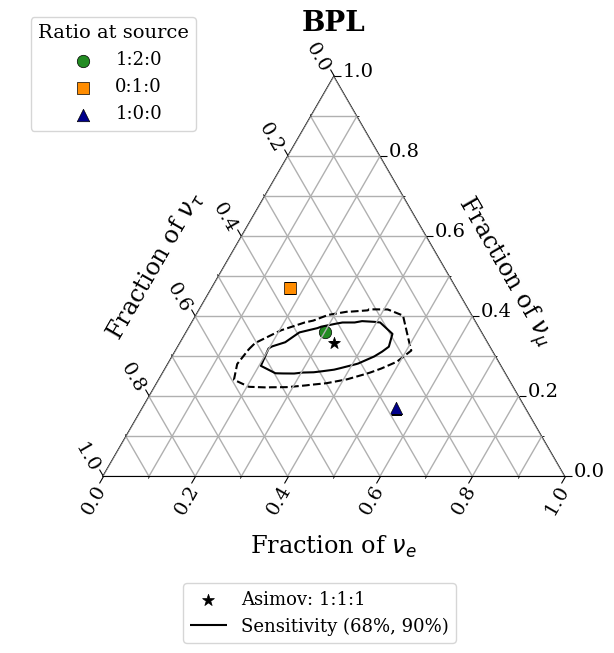

In [10]:
names = [
"globalfit_double_no_hybrid_hese_BPL_noinel_nosyst",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"BPL",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_hese_BPL_noinel_nosyst.png")


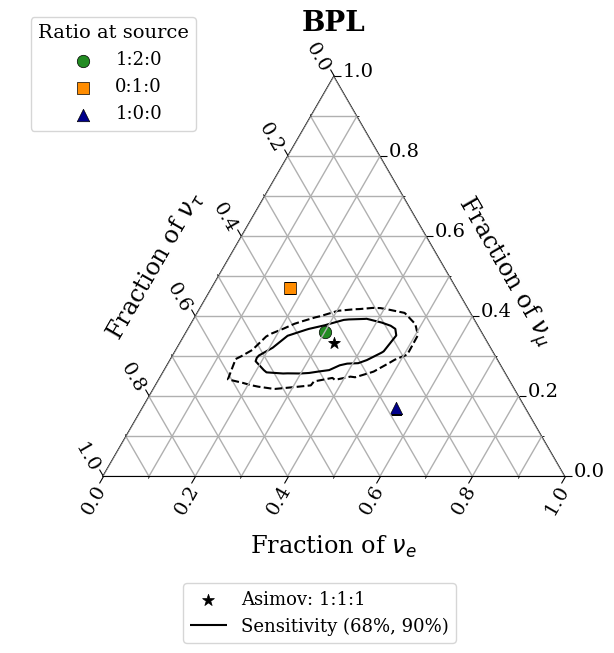

In [ ]:
names = [
"globalfit_double_no_hybrid_hese_BPL_noinel",
]
labels = [
    "Sensitivity",
]

C = plot_contour( data = data,
                  name = names[0],
                  label = labels[0],
                  levels = ["68%", "90%"],
                  title = r"BPL",
                  scenarios=True,
                  show_ts_labels=False,
                  savepath = f"{plotting_path}/globalfit_double_no_hybrid_hese_BPL_noinel.png")


Let's make some comparison plots

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processi

Area ratio (globalfit_double_no_hybrid_hese_BPL_noinel_nosyst / globalfit_double_no_hybrid_hese_BPL_noinel_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_BPL_noinel / globalfit_double_no_hybrid_hese_BPL_noinel_nosyst) at 68%: 1.0720


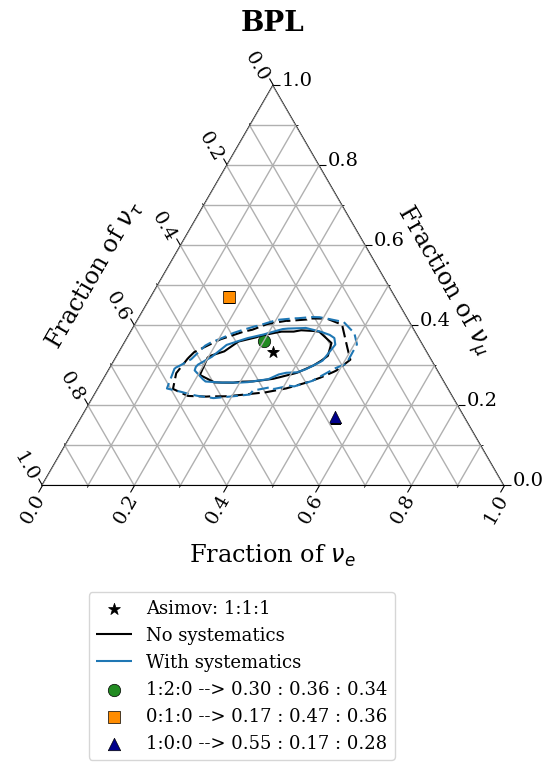

In [16]:
# compare_syst_globalfit_double_no_hybrid_hese_BPL_noinel
names = [
"globalfit_double_no_hybrid_hese_BPL_noinel_nosyst",
"globalfit_double_no_hybrid_hese_BPL_noinel",
]
labels = [
    "No systematics",
    "With systematics",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%", "90%"],
                  title = r"BPL",
                  scenarios = True,
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_hese_BPL_noinel.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_BPL_noinel_nosyst", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_hese_SPL_noinel_nosyst / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_SPL_noinel / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 1.0506


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

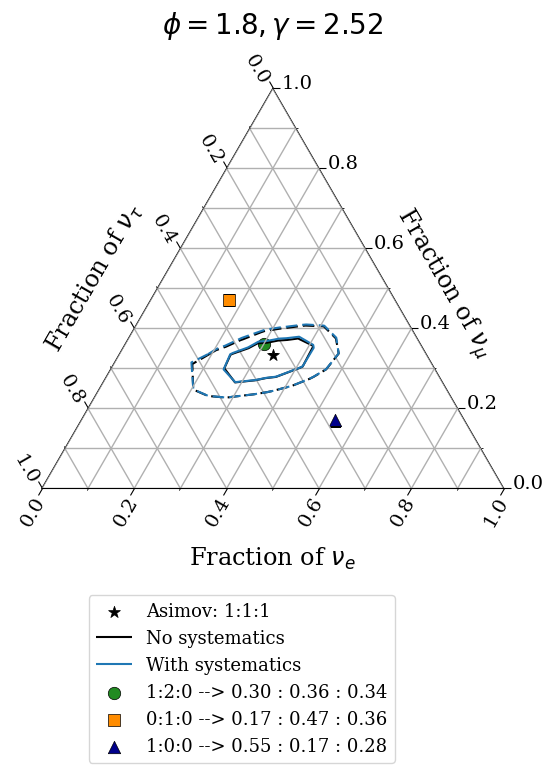

In [17]:
# compare_syst_globalfit_double_no_hybrid_hese_SPL_noinel
names = [
"globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
"globalfit_double_no_hybrid_hese_SPL_noinel",
]
labels = [
    "No systematics",
    "With systematics",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  savepath = f"{plotting_path}/compare_syst_globalfit_double_no_hybrid_hese_SPL_noinel.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_SPL_noinel_nosyst", levels=["68%"] )

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_hese_SPL_noinel_nosyst / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_SPL_nosyst / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 1.1155


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:229: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

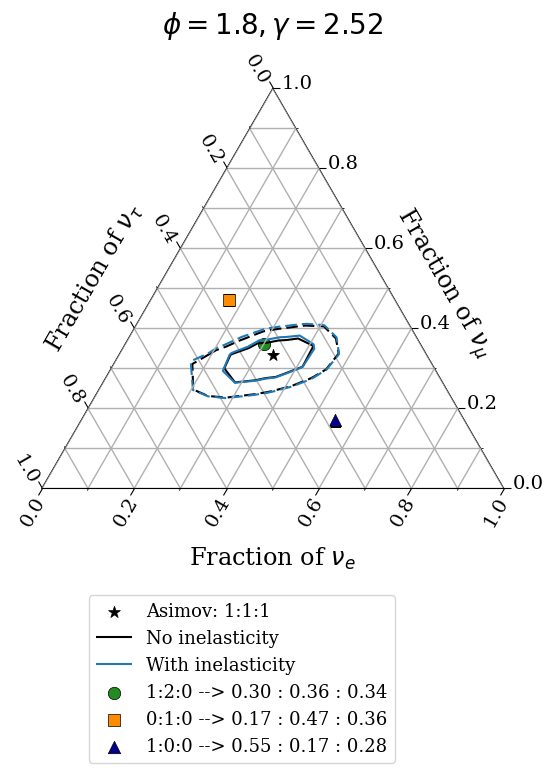

In [20]:
# compare_inel_globalfit_double_no_hybrid_hese_SPL
names = [
"globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
"globalfit_double_no_hybrid_hese_SPL_nosyst",
]
labels = [
    "No inelasticity",
    "With inelasticity",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  savepath = f"{plotting_path}/compare_inel_globalfit_double_no_hybrid_hese_SPL.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_SPL_noinel_nosyst", levels=["68%"] )

Compare my v2 with my v3 dataset. The v3 is the new nnmfit frame i got from zheyang

/data/user/tvaneede/utils/Ternary.py:74: UserWarning: First parameter to grid() is false, but line properties are supplied. The grid will be enabled.
  ax.xaxis.grid(*args, **kwargs)


Area ratio (globalfit_double_no_hybrid_hese_SPL_noinel_nosyst / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 1.0000
Area ratio (globalfit_double_no_hybrid_hese_SPL_noinel_nosyst_v3 / globalfit_double_no_hybrid_hese_SPL_noinel_nosyst) at 68%: 0.9799


/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour_obj.collections[i].get_paths()
/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/notebooks/plot_utils_triangle.py:226: MatplotlibDeprecationWarning: The collections attribute was deprecated in Matplotlib 3.8 and will be removed in 3.10.
  paths = contour

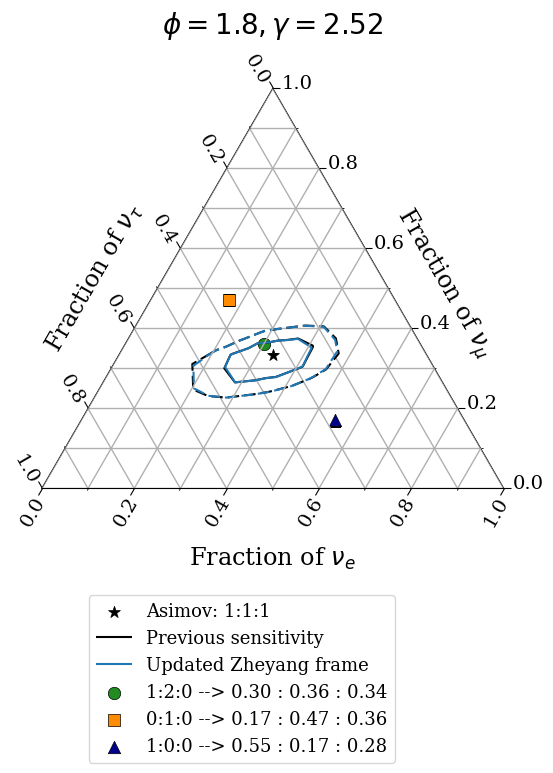

In [15]:
# compare_zheyang_globalfit_double_no_hybrid_hese_SPL_noinel_nosyst
names = [
"globalfit_double_no_hybrid_hese_SPL_noinel_nosyst",
"globalfit_double_no_hybrid_hese_SPL_noinel_nosyst_v3",
]
labels = [
    "Previous sensitivity",
    "Updated Zheyang frame",
]
C = compare_contours( data = data,
                  names = names,
                  labels = labels,
                  levels = ["68%", "90%"],
                  title = r"$\phi=1.8,\gamma=2.52$",
                  scenarios=True,
                  savepath = f"{plotting_path}/compare_zheyang_globalfit_double_no_hybrid_hese_SPL_noinel_nosyst.png")

for name in names: compare_area( C, alt_key=name, base_key="globalfit_double_no_hybrid_hese_SPL_noinel_nosyst", levels=["68%"] )